<a href="https://colab.research.google.com/github/whateveri/models/blob/Grad-CAM/simple_GradCAM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 30.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 42.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 45.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 10.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 33.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [1]:
import torch

from torchvision import models, transforms
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image


# Grad-CAM based on ResNet-50

In [24]:

import urllib.request

img_path=os.path.join(os.getcwd(),"Smiling_dog.jpg")
print(img_path)

img=Image.open(img_path).convert("RGB")

#img_array=np.array(img)
transform=transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406], [0.229,0.224,0.225])
])


input_tensor=transform(img).unsqueeze(0)
print(f'tensor shape:{input_tensor.shape}') #(1,C,H,W)



#load class labels
url="https://raw.githubusercontent.com/pytorch/hub/master/imagenet_classes.txt"
with urllib.request.urlopen(url) as f:
    class_names=[line.strip().decode("utf-8") for line in f.readlines()]




/content/Smiling_dog.jpg
tensor shape:torch.Size([1, 3, 224, 224])


In [25]:
#get the gradient and features of the image
features=[]
gradients=[]


def forward_hook(module,input,output):
    print(f'feature mape shape:{output.shape}') #feature map shape:(B,C,H,W), features shape:(1,B,C,H,W)
    features.append(output.detach())

def backward_hook(module,grad_input,grad_output):
    gradients.append(grad_output[0].detach())

feature mape shape:torch.Size([1, 2048, 7, 7])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1


/tmp/ipython-input-27-3403795925.py:68: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=cm.get_cmap('jet')


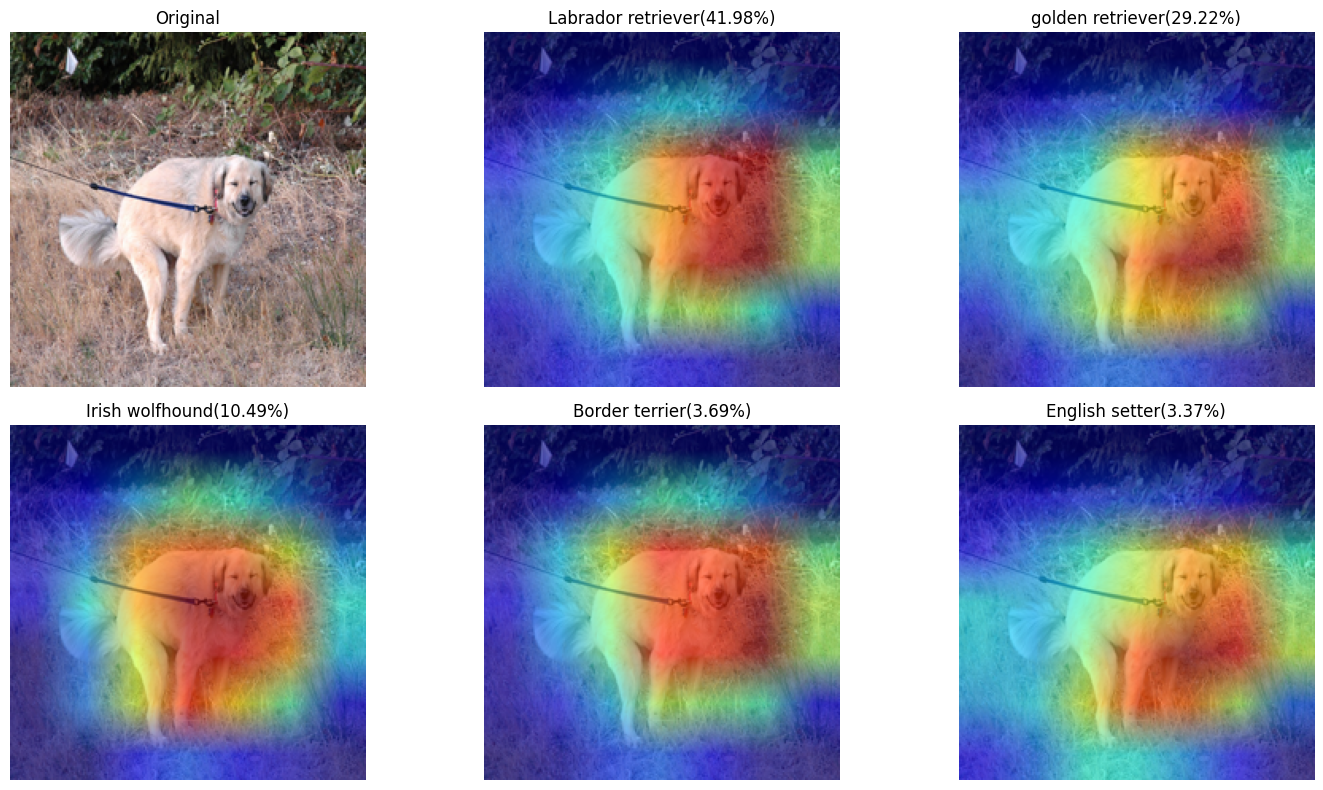

In [27]:
import cv2
import matplotlib.cm as cm

model=models.resnet50(pretrained=True)
model.eval()

#get the last convolution layer of the model
final_conv=model.layer4[2].conv3
features.clear()
gradients.clear()



h1=final_conv.register_forward_hook(forward_hook)
h2=final_conv.register_backward_hook(backward_hook)

#forward
output=model(input_tensor)
probs=torch.nn.functional.softmax(output,dim=1)[0]
top5_probs,top5_indices=torch.topk(probs,k=5)
#pred_class=output.argmax().item()


#compute gradCAM
heatmaps=[]
for class_idx in top5_indices:
    model.zero_grad()
    gradients.clear()
    features.clear()

    #re-run forward to trigger backward
    output=model(input_tensor)

    class_score=output[0,class_idx]
    class_score.backward(retain_graph=True)

    pooled_gradients=torch.mean(gradients[0],dim=[0,2,3]) #gradients[0] shape (1, C, H, W), ->(C,)

    #feature maps
    print(f'features len:{len(features)}')
    A=features[0][0] #shape(C,H,W)
    for i in range(pooled_gradients.shape[0]):
        A[i,:,:]*=pooled_gradients[i]
    heatmap = A.mean(dim=0).cpu().numpy() #shape(H,W)
    heatmap = np.maximum(heatmap,0) #negative->0
    heatmap /= np.max(heatmap) #regularization ,value in [0,1]

    heatmaps.append((class_idx.item(),heatmap))

h1.remove()
h2.remove()

#visualize

img_array=np.array(img.resize((224,224)))

plt.figure(figsize=(15,8))

#origial img
plt.subplot(2,3,1)
plt.imshow(img_array)
plt.title('Original')
plt.axis('off')

#show heatmap for 5-top classes

for i,(cls_idx,heatmap) in enumerate(heatmaps):
    colormap=cm.get_cmap('jet')
    heatmap_color=colormap(heatmap)[:,:,:3] #RGBA -> RGB,shape:(H,W,3)
    heatmap_color=np.uint8(255 * heatmap_color)

    #resize
    heatmap_pil=Image.fromarray(heatmap_color).resize((224,224),resample=Image.BILINEAR)
    heatmap_resized=np.array(heatmap_pil)

    superimposed_img=(0.6*heatmap_resized + 0.4 * img_array).astype(np.uint8)

    plt.subplot(2,3,i+2)
    plt.imshow(superimposed_img)
    plt.title(f'{class_names[cls_idx]}({top5_probs[i].item():.2%})')
    plt.axis('off')

plt.tight_layout()
plt.show()





# Grad-CAM based on ResNet-101

feature mape shape:torch.Size([1, 2048, 7, 7])
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1
feature mape shape:torch.Size([1, 2048, 7, 7])
features len:1


/tmp/ipython-input-30-2146206469.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=cm.get_cmap('jet')


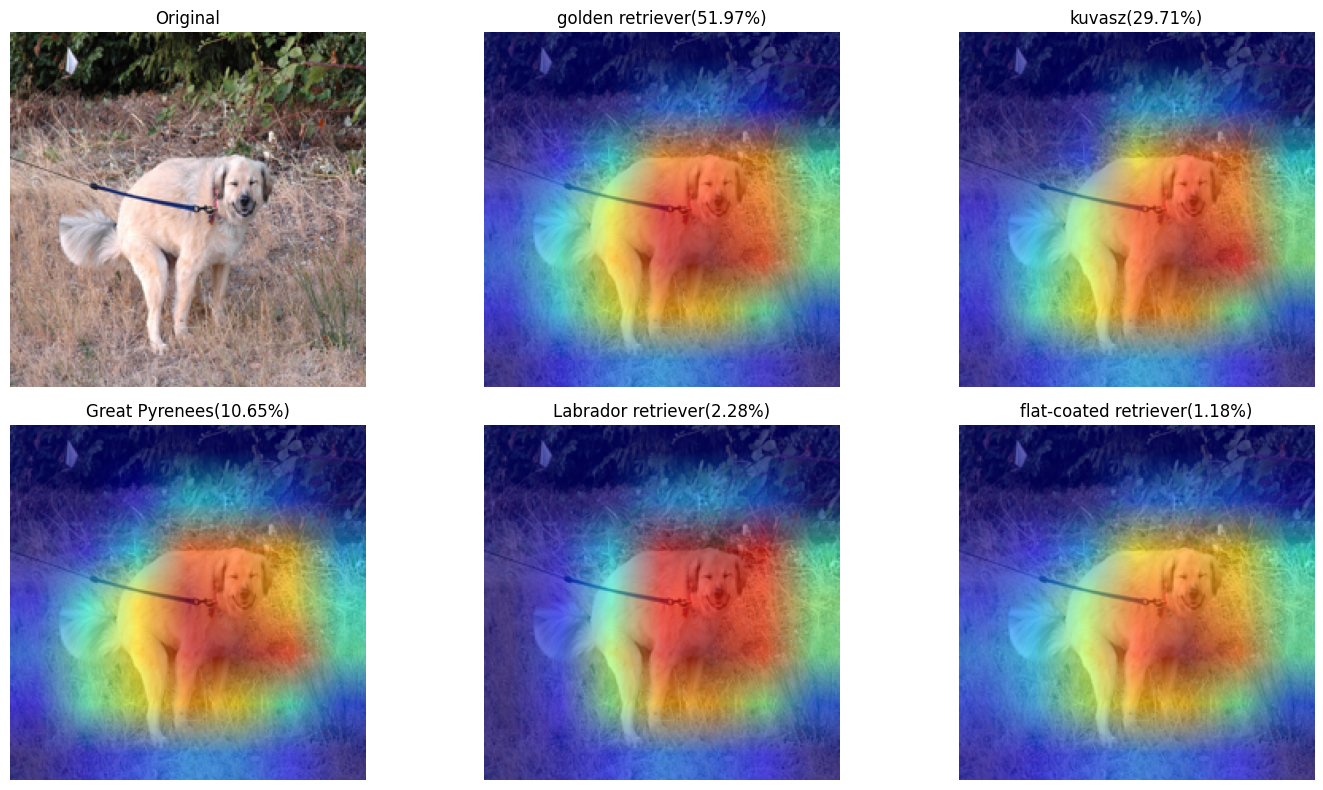

In [30]:
model2=models.resnet101(pretrained=True)
model2.eval()

#get the last convolution layer of the model
final_conv2=model2.layer4[2].conv3
features.clear()
gradients.clear()



h1=final_conv2.register_forward_hook(forward_hook)
h2=final_conv2.register_backward_hook(backward_hook)

#forward
output=model2(input_tensor)
probs=torch.nn.functional.softmax(output,dim=1)[0]
top5_probs,top5_indices=torch.topk(probs,k=5)
#pred_class=output.argmax().item()


#compute gradCAM
heatmaps2=[]
for class_idx in top5_indices:
    model2.zero_grad()
    gradients.clear()
    features.clear()

    #re-run forward to trigger backward
    output=model2(input_tensor)

    class_score2=output[0,class_idx]
    class_score2.backward(retain_graph=True)

    pooled_gradients=torch.mean(gradients[0],dim=[0,2,3]) #gradients[0] shape (1, C, H, W), ->(C,)

    #feature maps
    print(f'features len:{len(features)}')
    A=features[0][0] #shape(C,H,W)
    for i in range(pooled_gradients.shape[0]):
        A[i,:,:]*=pooled_gradients[i]
    heatmap = A.mean(dim=0).cpu().numpy() #shape(H,W)
    heatmap = np.maximum(heatmap,0) #negative->0
    heatmap /= np.max(heatmap) #regularization ,value in [0,1]

    heatmaps2.append((class_idx.item(),heatmap))

h1.remove()
h2.remove()

#visualize

img_array=np.array(img.resize((224,224)))

plt.figure(figsize=(15,8))

#origial img
plt.subplot(2,3,1)
plt.imshow(img_array)
plt.title('Original')
plt.axis('off')

#show heatmap for 5-top classes

for i,(cls_idx,heatmap) in enumerate(heatmaps2):
    colormap=cm.get_cmap('jet')
    heatmap_color=colormap(heatmap)[:,:,:3] #RGBA -> RGB,shape:(H,W,3)
    heatmap_color=np.uint8(255 * heatmap_color)

    #resize
    heatmap_pil=Image.fromarray(heatmap_color).resize((224,224),resample=Image.BILINEAR)
    heatmap_resized=np.array(heatmap_pil)

    superimposed_img=(0.6*heatmap_resized + 0.4 * img_array).astype(np.uint8)

    plt.subplot(2,3,i+2)
    plt.imshow(superimposed_img)
    plt.title(f'{class_names[cls_idx]}({top5_probs[i].item():.2%})')
    plt.axis('off')

plt.tight_layout()
plt.show()






# Grad-CAM based on VGG16

/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth
100%|██████████| 528M/528M [00:07<00:00, 69.6MB/s]


feature mape shape:torch.Size([1, 512, 14, 14])


/usr/local/lib/python3.11/dist-packages/torch/nn/modules/module.py:1830: FutureWarning: Using a non-full backward hook when the forward contains multiple autograd Nodes is deprecated and will be removed in future versions. This hook will be missing some grad_input. Please use register_full_backward_hook to get the documented behavior.
  self._maybe_warn_non_full_backward_hook(args, result, grad_fn)


feature mape shape:torch.Size([1, 512, 14, 14])
features len:1
feature mape shape:torch.Size([1, 512, 14, 14])
features len:1
feature mape shape:torch.Size([1, 512, 14, 14])
features len:1
feature mape shape:torch.Size([1, 512, 14, 14])
features len:1
feature mape shape:torch.Size([1, 512, 14, 14])
features len:1


/tmp/ipython-input-31-3324583224.py:65: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap=cm.get_cmap('jet')


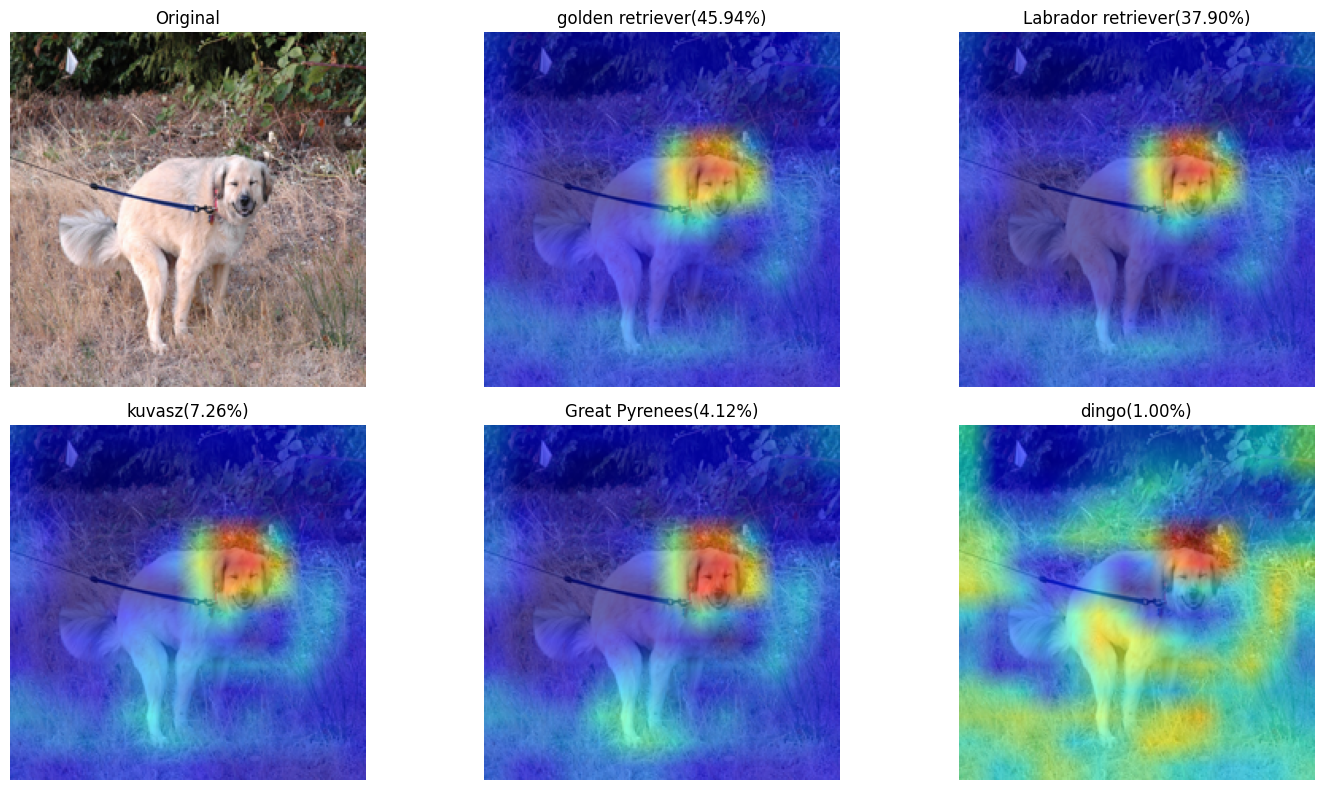

In [31]:
model3=models.vgg16(pretrained=True)
model3.eval()

#get the last convolution layer of the model
final_conv3=model3.features[28]
features.clear()
gradients.clear()



h1=final_conv3.register_forward_hook(forward_hook)
h2=final_conv3.register_backward_hook(backward_hook)

#forward
output=model3(input_tensor)
probs=torch.nn.functional.softmax(output,dim=1)[0]
top5_probs,top5_indices=torch.topk(probs,k=5)
#pred_class=output.argmax().item()


#compute gradCAM
heatmaps3=[]
for class_idx in top5_indices:
    model2.zero_grad()
    gradients.clear()
    features.clear()

    #re-run forward to trigger backward
    output=model3(input_tensor)

    class_score3=output[0,class_idx]
    class_score3.backward(retain_graph=True)

    pooled_gradients=torch.mean(gradients[0],dim=[0,2,3]) #gradients[0] shape (1, C, H, W), ->(C,)

    #feature maps
    print(f'features len:{len(features)}')
    A=features[0][0] #shape(C,H,W)
    for i in range(pooled_gradients.shape[0]):
        A[i,:,:]*=pooled_gradients[i]
    heatmap = A.mean(dim=0).cpu().numpy() #shape(H,W)
    heatmap = np.maximum(heatmap,0) #negative->0
    heatmap /= np.max(heatmap) #regularization ,value in [0,1]

    heatmaps3.append((class_idx.item(),heatmap))

h1.remove()
h2.remove()

#visualize

img_array=np.array(img.resize((224,224)))

plt.figure(figsize=(15,8))

#origial img
plt.subplot(2,3,1)
plt.imshow(img_array)
plt.title('Original')
plt.axis('off')

#show heatmap for 5-top classes

for i,(cls_idx,heatmap) in enumerate(heatmaps3):
    colormap=cm.get_cmap('jet')
    heatmap_color=colormap(heatmap)[:,:,:3] #RGBA -> RGB,shape:(H,W,3)
    heatmap_color=np.uint8(255 * heatmap_color)

    #resize
    heatmap_pil=Image.fromarray(heatmap_color).resize((224,224),resample=Image.BILINEAR)
    heatmap_resized=np.array(heatmap_pil)

    superimposed_img=(0.6*heatmap_resized + 0.4 * img_array).astype(np.uint8)

    plt.subplot(2,3,i+2)
    plt.imshow(superimposed_img)
    plt.title(f'{class_names[cls_idx]}({top5_probs[i].item():.2%})')
    plt.axis('off')

plt.tight_layout()
plt.show()

